In [1]:
import numpy as np
import matplotlib.pyplot as plt   

mu_H20 = -76.36450433
Eh2eV = 27.2114079527
pre_factor = 0.0591 # RTln10
dim = 3
trathure = 1e-4
n_repr = 2

class PsiClassError(Exception):
    def __init__(self, massage = "Undefined"):
        super().__init__(massage)

class DefinitionError(Exception):
    def __init__(self, massage = "Wrong"):
        super().__init__(massage)

def co(option: str) -> int:
    if option == "pH":
        return 0
    if option == "E":
        return 1
    raise DefinitionError()

def convert_coef(GFE_rec, number_of_O, number_of_H, weight, Q=0, log10_of_conc=1):
    GFE_part = (1/weight)*GFE_rec
    water_part = (1/weight)*(-mu_H20*number_of_O)
    pre_pH = (1/weight)*(-0.0591*(2*number_of_O - number_of_H))
    pre_E = (1/weight)*(-(2*number_of_O - number_of_H + Q))
    conc_part = (1/weight)*0.0591*log10_of_conc
    return (GFE_part, conc_part, water_part, pre_pH, pre_E)

def get_grid(pH_grid: list, E_grid: list, option: str) -> list[list[tuple[float, float]],]:
    co(option)
    grid_2d = None
    if option == "pH":
        grid_2d = [*map(
            lambda x: [*map(
                lambda y: (x, y),
                E_grid
            )],
            pH_grid
        )]
    if option == "E":
        grid_2d = [*map(
            lambda y: [*map(
                lambda x: (x, y),
                pH_grid
            )],
            E_grid
        )]
    return grid_2d  

def repack_points(list_of_points: list[tuple[float, float],]) -> tuple[list[float,], list[float,]]:
    x_or_y_values = []
    Psi_values = []
    for point in list_of_points:
        x_or_y_values.append(point[0])
        Psi_values.append(point[1])
    return (x_or_y_values, Psi_values)



class Psi():
    def __init__(self, GFE_part, conc_part, water_part, pre_pH, pre_E, label):
        self.G = GFE_part
        self.c = conc_part
        self.w = water_part
        self.pH = pre_pH
        self.E = pre_E
        self.label = label
    
    def __mul__(self, other):
        if isinstance(other, (int, float)):
            return Psi(
                *[*map(lambda x: other*x, [self.G, self.c, self.w, self.pH, self.E])],
                label=f"{round(other, n_repr)}{self.label}"
                )
        else:
            raise PsiClassError()
    
    def __rmul__(self, other):
        return self.__mul__(other)
    
    def __add__(self, other):
        if isinstance(other, Psi):
            return Psi(
                self.G + other.G,
                self.c + other.c,
                self.w + other.w,
                self.pH + other.pH,
                self.E + other.E,
                f"{self.label} + {other.label}"
            )
        else:
            raise PsiClassError()
    
    def get_plane(self) -> callable:
        return lambda pH, E: Eh2eV*(self.G + self.c + self.w) + Eh2eV*self.pH*(pH) + Eh2eV*self.E*E

    def __repr__(self):
        return f"{self.label}"#: {round(self.G, n_repr)} + {round(self.c, n_repr)} + {round(self.w, n_repr)} + {round(self.pH, n_repr)}*pH + {round(self.E, n_repr)}*E"



def get_phase_multiplier(list_of_sulfurs):
    def add_sulfur(list_of_basic_phases, x_fact = 1/12):
        data = []
        y = True
        for phase in list_of_basic_phases:
            if "S" in phase.label:
                if "NiS2" in phase.label:
                    x = 0
                    y = False
                else:
                    x = x_fact
            else:
                x = 0
            if y:
                data += [((1/(3-x))*phase + ((2-x)/(3-x))*SulfIon) for SulfIon in list_of_sulfurs]
            else:
                data += [phase]
        return data
    return add_sulfur

def extrapolate(defect: Psi, init: Psi, x: float) -> Psi:
    x_max = 1/12
    ext = (1-x/x_max)*init + x/x_max*defect
    ext.label = defect.label
    return ext

def add_oxygen(phase: Psi, oxygen: Psi, x: float) -> Psi:
    ext = (1/(1+x))*phase + (x/(1+x))*oxygen
    print(ext.label)
    return ext

option = "pH"

def create_PD_dataset(pH_grid, E_grid, Phases) -> dict[int:dict[str:list[tuple[float, float],],],]:

    def find_min(point):
        i_min, psi_min = sorted(
            map(
                lambda pair: (pair[0], pair[1](*point)),
                enumerate(list_of_planes)
                ), 
            key=lambda x: x[1]
            )[0]
        return (i_min, psi_min)

    def update_internal_dict(i_min, psi_min, point, dict_obj):
        key = Phases[i_min].label
        if dict_obj.get(key) is None:
            dict_obj[key] = []
        dict_obj[key].append((point[1-co(option)], psi_min))

    grid_2d = get_grid(pH_grid, E_grid, option)
    
    list_of_planes = [*map(
        lambda Phase: Phase.get_plane(),
        Phases
        )]
    
    dataset = {}

    for grid_1d in grid_2d:
        dataset_slice = {}
        [*map(
            lambda point: update_internal_dict(
                *find_min(point),
                point,
                dict_obj=dataset_slice
                ),
            grid_1d
            )]

        dataset[grid_1d[0][co(option)]] = dataset_slice.copy()
    
    return dataset

def compress_PD_dataset(DS: dict[float:dict[str: list[tuple[float, float],]],]) -> dict[float:dict[str, tuple[float, float],]]:

    def dump(list_obj, key, label):
        data = list_obj.copy()
        DS[key][label] = (data[0][0], data[-1][0])

    [*map(
        lambda key: [*map(
            lambda label: dump(DS[key][label], key, label),
            DS[key].keys()
        )],
        DS.keys()
    )]

    return DS

def represent_PD_dataset(dataset: dict[float:dict[str, tuple[float, float],]]) -> dict[str:list[tuple[float, float],],]:
    DS = {}

    def arrogate(pH, label):
        E_left, E_right = dataset[pH][label]

        if DS.get(label) is None:
            DS[label] = []

        DS[label] += [(pH, E_left), (pH, E_right)]
    
    [*map(
        lambda pH: [*map(
            lambda label: arrogate(pH, label),
            dataset[pH]
        )],
        dataset.keys()
    )]

    return DS

def represent_PD_dataset_to_draw(DS: dict[str:list[tuple[float, float],],]) -> dict[str: tuple[list[float, float], list[float, float]],]:

    for label in DS.keys():
        pHs = []
        Es = []
        for point in DS[label]:
            pHs.append(point[0])
            Es.append(point[1])
        
        DS[label] = (pHs.copy(), Es.copy())
    return DS

def draw_PD_dataset(dataset: dict[str: tuple[list[float, float], list[float, float]],], limits=None, save_png = False) -> None:
    fig, ax = plt.subplots()
    for label in dataset.keys():
        tuple_of_axis = dataset[label]
        ax.plot(
            *tuple_of_axis,
            "-",
            linewidth=1,
            label=f"{label}"
            )
    
    if not(limits is None):
        ax.set(**limits)
    
    ax.legend(fontsize=7)
    if save_png:
        plt.savefig(f'PD.png', dpi=300)
    
    plt.show()


('Ni_s', 0.0)
('Ni2+', -46.627128486659544)
('Ni(OH)2', -61.055991155608424)
('NiHO2', -89.35946999222135)
('NiO2', -112.16384318740872)



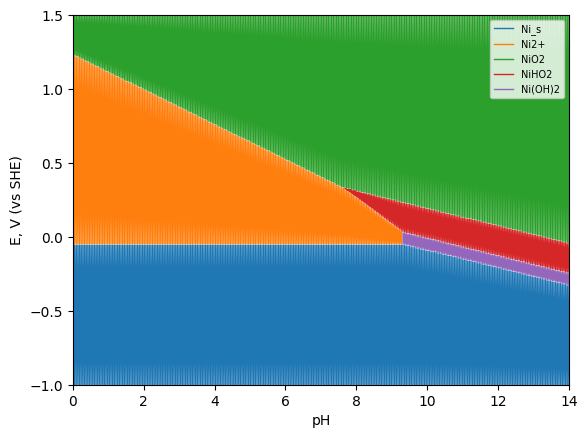

In [6]:
#NiOxHy - main phases 
Ni0 =  -1507.83870382

Ni_phases = {
    "Ni_s" : (Ni0 - Ni0, 0, 0, 1, 0, 0),
    "Ni2+" : (-1507.58361782 - Ni0, 0, 0, 1, 2, -6),
}
NiOxHySz = {
     "Ni(OH)2":(-1659.566316979865 - Ni0, 2, 2, 1, 0, 0),

     "NiHO2":(-6635.935479250409  - Ni0 * 4, 8, 4, 4, 0, 0),

     "NiO2":(-1658.199334401652 - Ni0, 2, 0, 1, 0, 0),
}
el_phases = {
    **Ni_phases,
    **NiOxHySz
    }


list_of_phases = [Psi(*convert_coef(*el_phases[key]), label=key) for key in el_phases.keys()] 
Ni0, Ni2, NiOH_0, NiHO2_0, NiO2_0 = list_of_phases

Phases = [
    Ni0,
    Ni2,
    NiOH_0,
    NiHO2_0,
    NiO2_0,
]

for point in [(13.8, 0.807),]:
    Psis = sorted([(phase.label, phase.get_plane()(*point)) for phase in Phases], key=lambda x: x[1], reverse=True)
    print(*Psis, sep="\n")
    print()


E_min, E_max = -1, 1.5
pH_min, pH_max = 0, 14
resolution = 300

pH_grid = np.linspace(pH_min, pH_max, resolution)
E_grid = np.linspace(E_min, E_max, resolution)

dataset = represent_PD_dataset_to_draw(
    represent_PD_dataset(
        compress_PD_dataset(
            create_PD_dataset(
                pH_grid,
                E_grid,
                Phases
                )
        )
    )
)

draw_PD_dataset(
    dataset,
    limits = {
    "xlim":(pH_min, pH_max), 
    "xlabel" : "pH", 
    "ylim": (E_min, E_max), 
    "ylabel": f"E, V (vs SHE)"
    },
    save_png=True
    )